# 🧩 Reusable Template: Multi-Stage Funnel Analysis
### Plug in your own tables and column names in the CONFIG cell — everything else runs as-is

Use this notebook as a starting point for *any* funnel project: signup funnels,
onboarding flows, hiring pipelines, checkout flows, etc. Only the **CONFIG** cell
below needs to change; the rest of the notebook is written generically against it.


## 1. CONFIG — edit this cell for your project

`STAGES` is an ordered list describing your funnel, earliest stage first. Each entry
needs:
- `name`: a human-readable label for plots/reports
- `path`: path to the CSV for that stage
- `key`: the join key column (must exist in every table, or be renamed to match — see Step 2 in the strategy notebook)
- `event_col`: the timestamp/event column unique to that stage (used to detect "did this user reach this stage")


In [1]:
STAGES = [
    {"name": "Visit",    "path": "data/visits.csv",   "key": "user_id", "event_col": "visit_time"},
    {"name": "Cart",     "path": "data/cart.csv",     "key": "user_id", "event_col": "cart_time"},
    {"name": "Checkout", "path": "data/checkout.csv", "key": "user_id", "event_col": "checkout_time"},
    {"name": "Purchase", "path": "data/purchase.csv", "key": "user_id", "event_col": "purchase_time"},
]

# If a stage's timestamp column should be parsed as a date, list it here.
PARSE_DATES = True

## 2. Load every stage generically

In [2]:
import pandas as pd

def load_stage(stage):
    parse_dates = [stage["event_col"]] if PARSE_DATES else None
    df = pd.read_csv(stage["path"], parse_dates=parse_dates)
    return df

tables = {stage["name"]: load_stage(stage) for stage in STAGES}

for name, df in tables.items():
    print(f"{name:12s}: {len(df)} rows, columns={list(df.columns)}")

Visit       : 2000 rows, columns=['user_id', 'visit_time']
Cart        : 620 rows, columns=['user_id', 'cart_time']
Checkout    : 410 rows, columns=['user_id', 'checkout_time']
Purchase    : 290 rows, columns=['user_id', 'purchase_time']


## 3. Inspect each stage

In [3]:
for name, df in tables.items():
    print(f"--- {name} ---")
    display(df.head(3))

--- Visit ---


,user_id,visit_time
0,user_0001,2024-01-01 02:39:00
1,user_0002,2024-01-01 03:18:00
2,user_0003,2024-01-01 03:35:00


--- Cart ---


,user_id,cart_time
0,user_0001,2024-01-01 02:49:00
1,user_0002,2024-01-01 04:08:00
2,user_0003,2024-01-01 04:25:00


--- Checkout ---


,user_id,checkout_time
0,user_0568,2024-01-26 19:42:00
1,user_0944,2024-02-12 12:18:00
2,user_0460,2024-01-22 02:40:00


--- Purchase ---


,user_id,purchase_time
0,user_1511,2024-03-09 16:18:00
1,user_0260,2024-01-12 10:57:00
2,user_0040,2024-01-02 18:02:00


## 4. Stage-by-stage drop-off, computed generically

This loops over every adjacent pair of stages in `STAGES` and computes the
left-join drop-off percentage — no hardcoded table names.

In [4]:
def dropoff_percent(upstream, downstream, key, downstream_event_col):
    merged = upstream.merge(downstream, how='left', on=key, suffixes=('', '_downstream'))
    dropped = merged[merged[downstream_event_col].isnull()]
    return len(dropped) / len(merged) * 100

dropoff_rows = []
for i in range(len(STAGES) - 1):
    up, down = STAGES[i], STAGES[i + 1]
    pct = dropoff_percent(
        tables[up["name"]], tables[down["name"]],
        up["key"], down["event_col"]
    )
    dropoff_rows.append({"transition": f'{up["name"]} -> {down["name"]}', "dropoff_pct": round(pct, 1)})

dropoff_table = pd.DataFrame(dropoff_rows)
dropoff_table

,transition,dropoff_pct
0,Visit -> Cart,69.0
1,Cart -> Checkout,33.9
2,Checkout -> Purchase,29.3


## 5. Full funnel merge (chained left joins), built generically

In [5]:
def build_full_funnel(stages, tables):
    key = stages[0]["key"]
    result = tables[stages[0]["name"]]
    for stage in stages[1:]:
        result = result.merge(tables[stage["name"]], how='left', on=key)
    return result

all_data = build_full_funnel(STAGES, tables)
print(all_data.shape)
all_data.head()

(2000, 5)


,user_id,visit_time,cart_time,checkout_time,purchase_time
0,user_0001,2024-01-01 02:39:00,2024-01-01 02:49:00,NaT,NaT
1,user_0002,2024-01-01 03:18:00,2024-01-01 04:08:00,2024-01-01 05:08:00,NaT
2,user_0003,2024-01-01 03:35:00,2024-01-01 04:25:00,2024-01-01 06:02:00,2024-01-01 06:04:00
3,user_0004,2024-01-01 03:35:00,NaT,NaT,NaT
4,user_0005,2024-01-01 04:59:00,NaT,NaT,NaT


## 6. Funnel summary table (counts + conversion from start)

In [6]:
funnel_summary = pd.DataFrame({
    "stage": [s["name"] for s in STAGES],
    "users": [len(tables[s["name"]]) for s in STAGES],
})
funnel_summary["pct_of_start"] = (
    funnel_summary["users"] / funnel_summary["users"].iloc[0] * 100
).round(1)
funnel_summary

,stage,users,pct_of_start
0,Visit,2000,100.0
1,Cart,620,31.0
2,Checkout,410,20.5
3,Purchase,290,14.5


## 7. Funnel chart, built generically

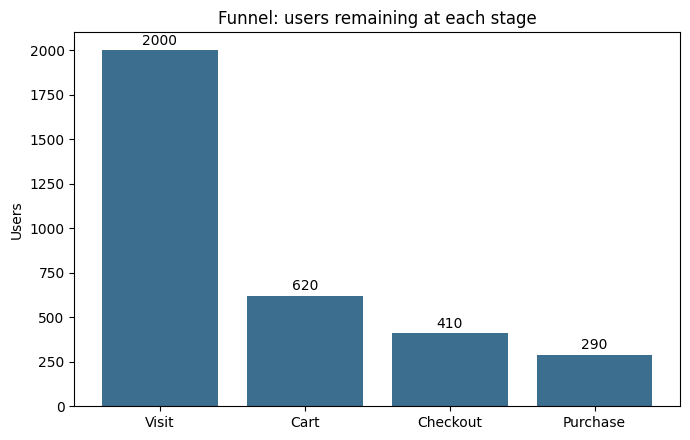

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(funnel_summary["stage"], funnel_summary["users"], color="#3b6e8f")
ax.set_title("Funnel: users remaining at each stage")
ax.set_ylabel("Users")
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{int(h)}", (bar.get_x() + bar.get_width() / 2, h),
                textcoords="offset points", xytext=(0, 4), ha="center")
plt.tight_layout()
plt.show()

## 8. Time-between-stages, for any two stages

Set `START_STAGE` / `END_STAGE` to any two stage names from your `STAGES` config
(they don't have to be adjacent — e.g. "Visit" to "Purchase").

In [8]:
START_STAGE = STAGES[0]["name"]
END_STAGE = STAGES[-1]["name"]

start_cfg = next(s for s in STAGES if s["name"] == START_STAGE)
end_cfg = next(s for s in STAGES if s["name"] == END_STAGE)

timed = tables[START_STAGE].merge(
    tables[END_STAGE], how="inner", on=start_cfg["key"]
)
timed["elapsed"] = timed[end_cfg["event_col"]] - timed[start_cfg["event_col"]]

print(f"{START_STAGE} -> {END_STAGE}")
print("Average elapsed:", timed["elapsed"].mean())
print("Median elapsed: ", timed["elapsed"].median())

Visit -> Purchase
Average elapsed: 0 days 04:21:20.896551
Median elapsed:  0 days 04:27:00


## 9. Weakest-link finder

In [9]:
weakest = dropoff_table.loc[dropoff_table["dropoff_pct"].idxmax()]
print(f"Weakest link: {weakest['transition']} ({weakest['dropoff_pct']}% drop-off)")

Weakest link: Visit -> Cart (69.0% drop-off)


## 10. Write-up (fill in after reviewing the numbers above)

- **Overall conversion, {first stage} to {last stage}:** _fill in_
- **Weakest link:** _fill in — from cell 9 above_
- **Typical time to convert:** _fill in — from cell 8 above_
- **Recommendation:** _fill in — tie it to the weakest link, be specific_
